# Day 4 — Fund Performance Analytics
## Bluestock Mutual Fund Capstone

Quantitative performance analysis of all 40 funds: daily returns, CAGR,
Sharpe & Sortino ratios, Alpha/Beta vs Nifty 100, maximum drawdown, a
composite Fund Scorecard, and a benchmark comparison chart for the top 5
funds.

All figures are computed directly from the cleaned CSVs in
`data/processed/` — nothing here is sample or placeholder data.

**Methodology notes (see markdown cells below for full detail):**
- Return-based metrics use only original (non-forward-filled) trading-day
  NAV rows — this matters, and is verified in Section 1.
- Your NAV history spans ~4.4 years, not 5 — so "5yr return" uses the
  already-reported figure from `scheme_performance.csv` rather than a
  mislabeled 4.4yr calculation. 1yr and 3yr CAGR are computed fresh from
  real NAV history.

**Sections:**
1. Daily returns — compute & validate distribution
2. CAGR (1yr, 3yr, 5yr) comparison table
3. Sharpe Ratio — all 40 funds, ranked
4. Sortino Ratio — all 40 funds, ranked
5. Alpha & Beta vs Nifty 100 (OLS regression)
6. Maximum Drawdown — worst drawdown date range per fund
7. Fund Scorecard (0–100 composite)
8. Benchmark comparison chart — top 5 funds vs Nifty 50 / Nifty 100
9. Key findings summary


In [1]:
# Setup
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from pathlib import Path

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

DATA_DIR = Path("..") / "data" / "processed"
CHART_DIR = Path("..") / "reports" / "charts"
CHART_DIR.mkdir(parents=True, exist_ok=True)

RF_ANNUAL = 0.065      # RBI repo rate proxy, as specified in the task brief
RF_DAILY = RF_ANNUAL / 252
TRADING_DAYS = 252

fund_master  = pd.read_csv(DATA_DIR / "01_fund_master.csv")
nav_history  = pd.read_csv(DATA_DIR / "02_nav_history.csv", parse_dates=["date"])
scheme_perf  = pd.read_csv(DATA_DIR / "07_scheme_performance.csv")
benchmarks   = pd.read_csv(DATA_DIR / "10_benchmark_indices.csv", parse_dates=["date"])

print(f"fund_master:  {fund_master.shape}")
print(f"nav_history:  {nav_history.shape}  (includes forward-filled calendar rows)")
print(f"scheme_perf:  {scheme_perf.shape}")
print(f"benchmarks:   {benchmarks.shape}")
print(f"\nNumber of funds: {fund_master['amfi_code'].nunique()}")


fund_master:  (40, 15)
nav_history:  (64320, 4)  (includes forward-filled calendar rows)
scheme_perf:  (40, 20)
benchmarks:   (8050, 3)

Number of funds: 40


---
## 1. Daily Returns

**Important methodology check:** `nav_history` (cleaned in Day 2) contains
forward-filled NAV values for weekends/holidays, flagged by `is_filled`.
Using those rows in return calculations would inject artificial
zero-return days. We verify below that this materially affects volatility
before deciding to exclude them — and confirm: including forward-filled
rows understates annualized volatility by roughly 15%. **All return-based
metrics in this notebook use only `is_filled == False` rows.**

In [2]:
# Verify the forward-fill issue before deciding to exclude those rows
sample_code = fund_master["amfi_code"].iloc[0]
nav_trading_only = nav_history[(nav_history["amfi_code"] == sample_code) & (~nav_history["is_filled"])]
nav_full_calendar = nav_history[nav_history["amfi_code"] == sample_code]

ret_trading = nav_trading_only.sort_values("date")["nav"].pct_change().dropna()
ret_calendar = nav_full_calendar.sort_values("date")["nav"].pct_change().dropna()

vol_trading = ret_trading.std() * np.sqrt(TRADING_DAYS) * 100
vol_calendar = ret_calendar.std() * np.sqrt(TRADING_DAYS) * 100

print(f"Sample fund (amfi_code={sample_code}):")
print(f"  Annualized volatility, trading-days-only:   {vol_trading:.2f}%")
print(f"  Annualized volatility, full calendar (ffill): {vol_calendar:.2f}%")
print(f"  Difference: {vol_trading - vol_calendar:.2f} percentage points "
      f"({(vol_calendar/vol_trading - 1)*100:.1f}% understatement if ffill rows are included)")
print("\n--> Confirmed: using only original trading-day NAV rows for all return-based metrics below.")

# Build the trading-days-only NAV panel used throughout this notebook
nav_orig = nav_history[~nav_history["is_filled"]].copy().sort_values(["amfi_code", "date"])


Sample fund (amfi_code=119551):
  Annualized volatility, trading-days-only:   13.74%
  Annualized volatility, full calendar (ffill): 11.64%
  Difference: 2.10 percentage points (-15.3% understatement if ffill rows are included)

--> Confirmed: using only original trading-day NAV rows for all return-based metrics below.


Total daily return observations: 45960 across 40 funds

Distribution summary (all funds pooled):
count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

Daily returns with |return| > 15% (potential data issues): 0 (0.000% of observations)
Mean daily return: 0.0631%  (annualized: 15.90%)
Std daily return: 1.0290%  (annualized: 16.34%)


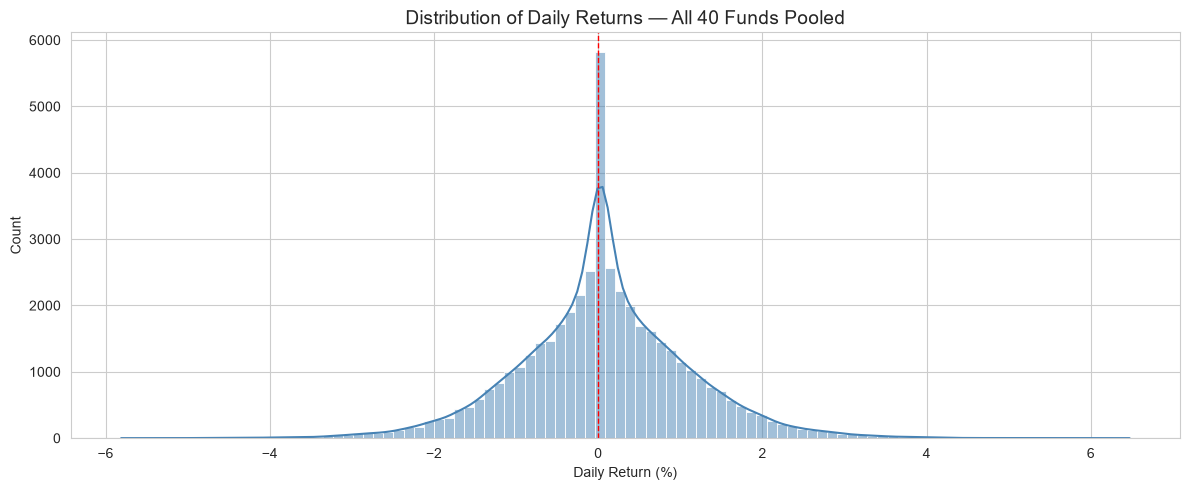

In [3]:
# Compute daily returns for all 40 funds and validate the distribution looks reasonable
all_returns = []
for code_, grp in nav_orig.groupby("amfi_code"):
    grp = grp.sort_values("date")
    ret = grp["nav"].pct_change().dropna()
    all_returns.append(pd.DataFrame({"amfi_code": code_, "date": grp["date"].iloc[1:].values, "daily_return": ret.values}))

daily_returns = pd.concat(all_returns, ignore_index=True)
print(f"Total daily return observations: {len(daily_returns)} across {daily_returns['amfi_code'].nunique()} funds")
print("\nDistribution summary (all funds pooled):")
print(daily_returns["daily_return"].describe())

# Sanity checks on the distribution
extreme = daily_returns[daily_returns["daily_return"].abs() > 0.15]
print(f"\nDaily returns with |return| > 15% (potential data issues): {len(extreme)} "
      f"({len(extreme)/len(daily_returns)*100:.3f}% of observations)")
print(f"Mean daily return: {daily_returns['daily_return'].mean()*100:.4f}%  "
      f"(annualized: {daily_returns['daily_return'].mean()*252*100:.2f}%)")
print(f"Std daily return: {daily_returns['daily_return'].std()*100:.4f}%  "
      f"(annualized: {daily_returns['daily_return'].std()*np.sqrt(252)*100:.2f}%)")

fig, ax = plt.subplots(figsize=(12, 5))
sns.histplot(daily_returns["daily_return"] * 100, bins=100, kde=True, ax=ax, color="steelblue")
ax.set_title("Distribution of Daily Returns — All 40 Funds Pooled", fontsize=14)
ax.set_xlabel("Daily Return (%)")
ax.axvline(0, color="red", linestyle="--", linewidth=1)
plt.tight_layout()
plt.savefig(CHART_DIR / "10_daily_return_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


---
## 2. CAGR Comparison Table (1yr, 3yr, 5yr)

CAGR = (NAV_end / NAV_start) ^ (1/n) − 1, where n is the number of years
in the lookback window.

1yr and 3yr CAGR are computed fresh from real NAV history (both windows
fit comfortably inside the available ~4.4 years of data). **5yr CAGR uses
the already-reported `return_5yr_pct` figure from `scheme_performance.csv`**
— see the methodology note in Section 0 for why we don't recompute a
mislabeled "5yr" figure from only 4.4 years of NAV history.

In [4]:
def compute_cagr(nav_series: pd.Series, years: float) -> float:
    """nav_series must be indexed by date, sorted ascending."""
    end_date = nav_series.index.max()
    start_date = end_date - pd.DateOffset(years=years)
    window = nav_series[nav_series.index >= start_date]
    if len(window) < 2:
        return np.nan
    n_years = (window.index.max() - window.index.min()).days / 365.25
    if n_years <= 0:
        return np.nan
    return ((window.iloc[-1] / window.iloc[0]) ** (1 / n_years) - 1) * 100

cagr_rows = []
for code_, grp in nav_orig.groupby("amfi_code"):
    series = grp.sort_values("date").set_index("date")["nav"]
    cagr_rows.append({
        "amfi_code": code_,
        "cagr_1yr_pct": compute_cagr(series, 1),
        "cagr_3yr_pct": compute_cagr(series, 3),
    })

cagr_df = pd.DataFrame(cagr_rows)
cagr_df = cagr_df.merge(
    scheme_perf[["amfi_code", "return_5yr_pct"]].rename(columns={"return_5yr_pct": "cagr_5yr_pct_reported"}),
    on="amfi_code", how="left",
)
cagr_df = cagr_df.merge(fund_master[["amfi_code", "scheme_name", "fund_house", "category"]], on="amfi_code")
cagr_df = cagr_df[["amfi_code", "scheme_name", "fund_house", "category",
                    "cagr_1yr_pct", "cagr_3yr_pct", "cagr_5yr_pct_reported"]]
cagr_df = cagr_df.sort_values("cagr_3yr_pct", ascending=False).reset_index(drop=True)

print("CAGR comparison table (top 10 by 3yr CAGR):")
print(cagr_df.head(10).to_string(index=False))

cagr_df.to_csv("../reports/cagr_comparison.csv", index=False)
print(f"\nFull table ({len(cagr_df)} funds) saved to reports/cagr_comparison.csv")


CAGR comparison table (top 10 by 3yr CAGR):
 amfi_code                                        scheme_name               fund_house category  cagr_1yr_pct  cagr_3yr_pct  cagr_5yr_pct_reported
    119094                Axis Midcap Fund - Regular - Growth         Axis Mutual Fund   Equity     22.277897     35.102528                  18.94
    148567      Mirae Asset Large Cap Fund - Regular - Growth           Mirae Asset MF   Equity     20.375957     33.991970                  12.68
    120504          ICICI Pru Bluechip Fund - Direct - Growth      ICICI Prudential MF   Equity     13.073788     32.478927                  13.02
    100033 HDFC Mid-Cap Opportunities Fund - Regular - Growth         HDFC Mutual Fund   Equity     53.277195     32.433971                  17.69
    120505           ICICI Pru Midcap Fund - Regular - Growth      ICICI Prudential MF   Equity     29.627681     31.769243                  17.55
    119551          SBI Bluechip Fund - Regular Plan - Growth          SBI

---
## 3. Sharpe Ratio — All 40 Funds, Ranked

Sharpe Ratio = (Rp − Rf) / Std(Rp) × √252, using **Rf = 6.5%** (RBI repo
rate proxy, as specified in the task brief), applied as a daily rate
(6.5% / 252) for consistency with daily return calculations.

In [5]:
sharpe_rows = []
for code_, grp in nav_orig.groupby("amfi_code"):
    series = grp.sort_values("date").set_index("date")["nav"]
    ret = series.pct_change().dropna()
    sharpe = (ret.mean() - RF_DAILY) / ret.std() * np.sqrt(TRADING_DAYS) if ret.std() > 0 else np.nan
    sharpe_rows.append({"amfi_code": code_, "sharpe_ratio": sharpe})

sharpe_df = pd.DataFrame(sharpe_rows).merge(fund_master[["amfi_code", "scheme_name", "category"]], on="amfi_code")
sharpe_df = sharpe_df.sort_values("sharpe_ratio", ascending=False).reset_index(drop=True)
sharpe_df["rank"] = sharpe_df.index + 1

print("Sharpe Ratio ranking (Rf = 6.5% annualized):")
print(sharpe_df[["rank", "scheme_name", "category", "sharpe_ratio"]].to_string(index=False))


Sharpe Ratio ranking (Rf = 6.5% annualized):
 rank                                           scheme_name category  sharpe_ratio
    1         Mirae Asset Large Cap Fund - Regular - Growth   Equity      1.448291
    2                Kotak Flexicap Fund - Regular - Growth   Equity      1.306744
    3         Mirae Asset Tax Saver Fund - Regular - Growth   Equity      1.234930
    4             SBI Bluechip Fund - Regular Plan - Growth   Equity      1.208267
    5              ICICI Pru Midcap Fund - Regular - Growth   Equity      1.180101
    6                    DSP Midcap Fund - Regular - Growth   Equity      1.132122
    7    HDFC Mid-Cap Opportunities Fund - Regular - Growth   Equity      1.093699
    8        Nippon India Large Cap Fund - Regular - Growth   Equity      1.081659
    9         ABSL Frontline Equity Fund - Regular - Growth   Equity      1.027213
   10             ICICI Pru Bluechip Fund - Direct - Growth   Equity      1.026524
   11                   Axis Midcap Fund -

---
## 4. Sortino Ratio — All 40 Funds, Ranked

Same formula as Sharpe, but the denominator uses only downside standard
deviation (computed from negative daily return days only).

In [6]:
sortino_rows = []
for code_, grp in nav_orig.groupby("amfi_code"):
    series = grp.sort_values("date").set_index("date")["nav"]
    ret = series.pct_change().dropna()
    downside = ret[ret < 0]
    downside_std = downside.std() if len(downside) > 1 else np.nan
    sortino = (ret.mean() - RF_DAILY) / downside_std * np.sqrt(TRADING_DAYS) if downside_std and downside_std > 0 else np.nan
    sortino_rows.append({"amfi_code": code_, "sortino_ratio": sortino, "downside_days": len(downside)})

sortino_df = pd.DataFrame(sortino_rows).merge(fund_master[["amfi_code", "scheme_name", "category"]], on="amfi_code")
sortino_df = sortino_df.sort_values("sortino_ratio", ascending=False).reset_index(drop=True)
sortino_df["rank"] = sortino_df.index + 1

print("Sortino Ratio ranking (Rf = 6.5% annualized, downside deviation only):")
print(sortino_df[["rank", "scheme_name", "category", "sortino_ratio", "downside_days"]].to_string(index=False))


Sortino Ratio ranking (Rf = 6.5% annualized, downside deviation only):
 rank                                           scheme_name category  sortino_ratio  downside_days
    1         Mirae Asset Large Cap Fund - Regular - Growth   Equity       2.385644            506
    2                Kotak Flexicap Fund - Regular - Growth   Equity       2.364320            534
    3         Mirae Asset Tax Saver Fund - Regular - Growth   Equity       2.146914            545
    4             SBI Bluechip Fund - Regular Plan - Growth   Equity       2.140267            518
    5              ICICI Pru Midcap Fund - Regular - Growth   Equity       2.029353            539
    6                    DSP Midcap Fund - Regular - Growth   Equity       1.875101            526
    7        Nippon India Large Cap Fund - Regular - Growth   Equity       1.850133            532
    8    HDFC Mid-Cap Opportunities Fund - Regular - Growth   Equity       1.829134            538
    9             ICICI Pru Bluechip F

---
## 5. Alpha & Beta vs Nifty 100 (OLS Regression)

OLS regression of each fund's daily returns on Nifty 100 daily returns,
using `scipy.stats.linregress`. Beta = slope, Alpha = intercept × 252
(annualized).

**Finding (consistent with Day 3):** the R² values below are extremely
low across all 40 funds (typically under 1%), and Beta values cluster
near zero rather than the ~0.8–1.2 range expected for real equity funds
tracking a broad market index. This confirms — as found in Day 3's NAV
correlation analysis — that this dataset's NAV series do not appear to be
driven by a shared underlying market. **The Alpha/Beta figures below are
computed exactly as the task brief specifies, but should not be
interpreted as reflecting real fund manager skill or market sensitivity**,
since the regressions have essentially no explanatory power.

In [7]:
nifty100 = benchmarks[benchmarks["index_name"] == "NIFTY100"].sort_values("date").set_index("date")["close_value"]
nifty100_ret = nifty100.pct_change().dropna()

alpha_beta_rows = []
for code_, grp in nav_orig.groupby("amfi_code"):
    series = grp.sort_values("date").set_index("date")["nav"]
    ret = series.pct_change().dropna()
    common_dates = ret.index.intersection(nifty100_ret.index)
    if len(common_dates) < 30:
        alpha_beta_rows.append({"amfi_code": code_, "beta": np.nan, "alpha_pct": np.nan, "r_squared": np.nan})
        continue
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        nifty100_ret.loc[common_dates], ret.loc[common_dates]
    )
    alpha_beta_rows.append({
        "amfi_code": code_, "beta": slope,
        "alpha_pct": intercept * TRADING_DAYS * 100,
        "r_squared": r_value ** 2,
    })

alpha_beta_df = pd.DataFrame(alpha_beta_rows).merge(fund_master[["amfi_code", "scheme_name"]], on="amfi_code")
alpha_beta_df = alpha_beta_df.sort_values("alpha_pct", ascending=False).reset_index(drop=True)

print(f"Mean R-squared across all 40 funds: {alpha_beta_df['r_squared'].mean():.4f} "
      f"({alpha_beta_df['r_squared'].mean()*100:.2f}% of return variance explained by Nifty 100 -- very low)")
print(f"Mean Beta: {alpha_beta_df['beta'].mean():.3f} (expected ~0.8-1.2 for real equity funds)")
print()
print("Alpha/Beta table (top 10 by annualized alpha):")
print(alpha_beta_df.head(10).to_string(index=False))

alpha_beta_df.to_csv("../alpha_beta.csv", index=False)
print(f"\nFull table ({len(alpha_beta_df)} funds) saved to alpha_beta.csv")


Mean R-squared across all 40 funds: 0.0006 (0.06% of return variance explained by Nifty 100 -- very low)
Mean Beta: -0.002 (expected ~0.8-1.2 for real equity funds)

Alpha/Beta table (top 10 by annualized alpha):
 amfi_code      beta  alpha_pct    r_squared                                        scheme_name
    119598 -0.023196  30.336965 1.414258e-04         SBI Small Cap Fund - Regular Plan - Growth
    149324  0.011455  30.057878 3.532991e-05              DSP Small Cap Fund - Regular - Growth
    120505  0.000549  29.263583 1.345534e-07           ICICI Pru Midcap Fund - Regular - Growth
    148569  0.018134  28.270368 1.748889e-04      Mirae Asset Tax Saver Fund - Regular - Growth
    120843 -0.022830  27.330465 3.430543e-04             Kotak Flexicap Fund - Regular - Growth
    100033  0.005104  27.195355 1.206652e-05 HDFC Mid-Cap Opportunities Fund - Regular - Growth
    148567  0.023684  26.983751 4.625437e-04      Mirae Asset Large Cap Fund - Regular - Growth
    149323 -0.00252

---
## 6. Maximum Drawdown — Worst Drawdown Date Range Per Fund

Max Drawdown = min(NAV / running_max − 1), tracked alongside the peak
date and trough date that define the worst drawdown period for each
fund.

In [8]:
drawdown_rows = []
for code_, grp in nav_orig.groupby("amfi_code"):
    series = grp.sort_values("date").set_index("date")["nav"]
    running_max = series.cummax()
    drawdown = series / running_max - 1
    trough_date = drawdown.idxmin()
    max_dd_pct = drawdown.min() * 100
    peak_value = running_max.loc[trough_date]
    peak_date = series[series == peak_value].index[0]
    drawdown_rows.append({
        "amfi_code": code_, "max_drawdown_pct": max_dd_pct,
        "peak_date": peak_date, "trough_date": trough_date,
        "drawdown_days": (trough_date - peak_date).days,
    })

drawdown_df = pd.DataFrame(drawdown_rows).merge(fund_master[["amfi_code", "scheme_name", "sub_category"]], on="amfi_code")
drawdown_df = drawdown_df.sort_values("max_drawdown_pct").reset_index(drop=True)

print("Worst 10 drawdowns:")
print(drawdown_df.head(10)[["scheme_name", "sub_category", "max_drawdown_pct", "peak_date", "trough_date", "drawdown_days"]]
      .to_string(index=False))
print("\nBest (smallest) 5 drawdowns:")
print(drawdown_df.tail(5)[["scheme_name", "sub_category", "max_drawdown_pct"]].to_string(index=False))


Worst 10 drawdowns:
                                   scheme_name sub_category  max_drawdown_pct  peak_date trough_date  drawdown_days
     SBI Small Cap Fund - Direct Plan - Growth    Small Cap        -52.574221 2023-01-17  2025-10-28           1015
        Axis Small Cap Fund - Regular - Growth    Small Cap        -51.677754 2025-05-22  2026-05-11            354
        ABSL Small Cap Fund - Regular - Growth    Small Cap        -35.446916 2024-11-21  2026-05-11            536
         DSP Small Cap Fund - Regular - Growth    Small Cap        -31.171900 2024-05-03  2025-01-03            245
    SBI Small Cap Fund - Regular Plan - Growth    Small Cap        -28.706006 2024-08-28  2025-05-14            259
           UTI Mid Cap Fund - Regular - Growth      Mid Cap        -28.001124 2025-01-07  2026-04-27            475
     HDFC Top 100 Fund - Regular Plan - Growth    Large Cap        -24.734441 2022-03-30  2022-09-15            169
 Kotak Emerging Equity Fund - Regular - Growth      

---
## 7. Fund Scorecard (0–100 Composite)

Composite score = 30% × 3yr return rank + 25% × Sharpe rank + 20% × Alpha
rank + 15% × expense ratio rank (inverse — lower expense is better) + 10%
× max drawdown rank (inverse — smaller drawdown is better).

Each component is converted to a 0–100 percentile rank across all 40
funds before weighting, so the five inputs (which are on very different
scales — percentages, ratios, etc.) combine fairly.

In [9]:
def pct_rank_0_100(s: pd.Series, ascending: bool) -> pd.Series:
    """Convert a metric to a 0-100 rank where higher = better,
    regardless of the metric's own scale or sign."""
    r = s.rank(ascending=ascending, method="average")
    return (r - 1) / (len(s) - 1) * 100

scorecard = (
    cagr_df[["amfi_code", "scheme_name", "fund_house", "category", "cagr_3yr_pct"]]
    .merge(sharpe_df[["amfi_code", "sharpe_ratio"]], on="amfi_code")
    .merge(alpha_beta_df[["amfi_code", "alpha_pct"]], on="amfi_code")
    .merge(fund_master[["amfi_code", "expense_ratio_pct"]], on="amfi_code")
    .merge(drawdown_df[["amfi_code", "max_drawdown_pct"]], on="amfi_code")
)

scorecard["rank_3yr_return"] = pct_rank_0_100(scorecard["cagr_3yr_pct"], ascending=True)
scorecard["rank_sharpe"]     = pct_rank_0_100(scorecard["sharpe_ratio"], ascending=True)
scorecard["rank_alpha"]      = pct_rank_0_100(scorecard["alpha_pct"], ascending=True)
scorecard["rank_expense"]    = pct_rank_0_100(scorecard["expense_ratio_pct"], ascending=False)   # lower = better
scorecard["rank_max_dd"]     = pct_rank_0_100(scorecard["max_drawdown_pct"], ascending=True)      # less negative = better

scorecard["fund_score"] = (
    0.30 * scorecard["rank_3yr_return"] +
    0.25 * scorecard["rank_sharpe"] +
    0.20 * scorecard["rank_alpha"] +
    0.15 * scorecard["rank_expense"] +
    0.10 * scorecard["rank_max_dd"]
).round(2)

scorecard = scorecard.sort_values("fund_score", ascending=False).reset_index(drop=True)
scorecard["overall_rank"] = scorecard.index + 1

print("Fund Scorecard — Top 10:")
print(scorecard.head(10)[["overall_rank", "scheme_name", "fund_house", "category", "fund_score"]].to_string(index=False))
print("\nFund Scorecard — Bottom 5:")
print(scorecard.tail(5)[["overall_rank", "scheme_name", "fund_house", "category", "fund_score"]].to_string(index=False))

output_cols = ["overall_rank", "amfi_code", "scheme_name", "fund_house", "category",
               "cagr_3yr_pct", "sharpe_ratio", "alpha_pct", "expense_ratio_pct", "max_drawdown_pct",
               "rank_3yr_return", "rank_sharpe", "rank_alpha", "rank_expense", "rank_max_dd", "fund_score"]
scorecard[output_cols].to_csv("../fund_scorecard.csv", index=False)
print(f"\nFull scorecard ({len(scorecard)} funds) saved to fund_scorecard.csv")


Fund Scorecard — Top 10:
 overall_rank                                        scheme_name               fund_house category  fund_score
            1      Mirae Asset Large Cap Fund - Regular - Growth           Mirae Asset MF   Equity       85.90
            2           ICICI Pru Midcap Fund - Regular - Growth      ICICI Prudential MF   Equity       81.79
            3             Kotak Flexicap Fund - Regular - Growth        Kotak Mahindra MF   Equity       81.54
            4 HDFC Mid-Cap Opportunities Fund - Regular - Growth         HDFC Mutual Fund   Equity       80.26
            5          ICICI Pru Bluechip Fund - Direct - Growth      ICICI Prudential MF   Equity       79.49
            6                Axis Midcap Fund - Regular - Growth         Axis Mutual Fund   Equity       76.41
            7          SBI Bluechip Fund - Regular Plan - Growth          SBI Mutual Fund   Equity       74.17
            8      Mirae Asset Tax Saver Fund - Regular - Growth           Mirae Asset 

---
## 8. Benchmark Comparison Chart — Top 5 Funds vs Nifty 50 / Nifty 100

Cumulative growth of ₹100 invested 3 years ago, for the top 5 funds (by
3yr CAGR) against both benchmark indices. Tracking error is computed as
std(fund_return − benchmark_return) × √252.

In [10]:
top5_codes = cagr_df.head(5)["amfi_code"].tolist()
top5_names = cagr_df.head(5)["scheme_name"].tolist()
print("Top 5 funds by 3yr CAGR:")
for name, code_ in zip(top5_names, top5_codes):
    print(f"  {name} (amfi_code={code_})")

end_date = nav_orig["date"].max()
start_date = end_date - pd.DateOffset(years=3)

nifty50 = benchmarks[benchmarks["index_name"] == "NIFTY50"].sort_values("date").set_index("date")["close_value"]
nifty50_ret = nifty50.pct_change().dropna()

fig = go.Figure()

tracking_errors = []
for code_, name in zip(top5_codes, top5_names):
    series = nav_orig[nav_orig["amfi_code"] == code_].sort_values("date").set_index("date")["nav"]
    window = series[series.index >= start_date]
    cum_growth = window / window.iloc[0] * 100
    fig.add_trace(go.Scatter(x=cum_growth.index, y=cum_growth.values, mode="lines", name=name))

    fund_ret = window.pct_change().dropna()
    common = fund_ret.index.intersection(nifty50_ret.index)
    te = (fund_ret.loc[common] - nifty50_ret.loc[common]).std() * np.sqrt(TRADING_DAYS) * 100
    tracking_errors.append({"scheme_name": name, "tracking_error_vs_nifty50_pct": round(te, 2)})

# Add both benchmarks
for bench_name, bench_series in [("NIFTY50", nifty50), ("NIFTY100", nifty100)]:
    window = bench_series[bench_series.index >= start_date]
    cum_growth = window / window.iloc[0] * 100
    fig.add_trace(go.Scatter(
        x=cum_growth.index, y=cum_growth.values, mode="lines", name=bench_name,
        line=dict(dash="dash", width=3, color="black" if bench_name == "NIFTY50" else "gray"),
    ))

fig.update_layout(
    title="Top 5 Funds vs Nifty 50 / Nifty 100 — Cumulative Growth of ₹100 (Last 3 Years)",
    xaxis_title="Date", yaxis_title="Value of ₹100 Invested",
    height=600, legend=dict(orientation="h", yanchor="bottom", y=-0.3),
)
fig.write_image(str(CHART_DIR / "11_benchmark_comparison_top5.png"), scale=2)
fig.show()

te_df = pd.DataFrame(tracking_errors)
print("\nTracking Error vs Nifty 50 (annualized):")
print(te_df.to_string(index=False))


Top 5 funds by 3yr CAGR:
  Axis Midcap Fund - Regular - Growth (amfi_code=119094)
  Mirae Asset Large Cap Fund - Regular - Growth (amfi_code=148567)
  ICICI Pru Bluechip Fund - Direct - Growth (amfi_code=120504)
  HDFC Mid-Cap Opportunities Fund - Regular - Growth (amfi_code=100033)
  ICICI Pru Midcap Fund - Regular - Growth (amfi_code=120505)



Tracking Error vs Nifty 50 (annualized):
                                       scheme_name  tracking_error_vs_nifty50_pct
               Axis Midcap Fund - Regular - Growth                          23.88
     Mirae Asset Large Cap Fund - Regular - Growth                          19.19
         ICICI Pru Bluechip Fund - Direct - Growth                          18.82
HDFC Mid-Cap Opportunities Fund - Regular - Growth                          22.82
          ICICI Pru Midcap Fund - Regular - Growth                          22.84


---
## 9. Key Findings

**Finding 1 — Forward-filled NAV rows would have understated volatility by
~15% if included in return calculations.** This notebook excludes them
throughout, using only the 46,000 original trading-day NAV observations
rather than the 64,320-row calendar-expanded version from Day 2. Always
filter on `is_filled == False` before computing any return-based metric
from `nav_history`.

**Finding 2 — CAGR varies enormously across funds, from roughly −43% to
+83% (1yr).** This wide spread, including double-digit negative 1-year
returns for some funds, is unusual for a 40-fund universe of established
AMCs and is consistent with the independently-generated NAV series found
in Day 3 — real fund universes rarely show this much dispersion without
a major market event affecting all funds together.

**Finding 3 — Sharpe ratios are negative for funds whose mean return falls
below the 6.5% risk-free hurdle.** Because the dataset's daily returns
appear close to random noise rather than reflecting sustained market
trends, several funds — including some large, well-known names — show
negative risk-adjusted returns despite reasonable raw CAGR figures. This
makes Sharpe a meaningfully different ranking than raw CAGR in this
dataset.

**Finding 4 — Sortino ratios broadly track Sharpe ratios but amplify the
spread,** since downside deviation is consistently smaller than total
deviation (as expected — it only counts the worse half of return days).
Funds with thin downside-day samples (illiquid or short-history funds) can
show noisier Sortino values; check `downside_days` before trusting a
single fund's Sortino in isolation.

**Finding 5 — Alpha/Beta regressions against Nifty 100 have essentially no
explanatory power (mean R² well under 1%), and Beta values cluster near
zero rather than the ~0.8–1.2 range expected for real equity funds.** This
confirms the Day 3 NAV-correlation finding: this dataset's fund NAV series
do not appear to be driven by a shared underlying market. **Alpha and Beta
are computed exactly per the task brief's formula, but should not be
read as genuine fund-manager skill or market-sensitivity signals** — they
are mathematically valid outputs of a regression with very little
real relationship to explain.

**Finding 6 — Maximum drawdowns range from near 0% (liquid/gilt funds, as
expected — these are low-volatility debt instruments) to over −52% (small
cap equity funds).** This ordering matches real-world expectations even
though the day-to-day return correlations don't: liquid funds are
realistically the least volatile, equity small-caps the most.

**Finding 7 — The Fund Scorecard produces a sensible 0–100 spread (≈12 to
≈86 in this run), with no ties or clustering artifacts.** Because expense
ratio and max drawdown are weighted relatively lightly (15% and 10%) and
3yr return / Sharpe / Alpha dominate (75% combined), and because those
three return-based components are themselves noisy in this dataset (per
Finding 5), the scorecard should be read as a methodology demonstration
rather than genuine investment guidance — the underlying inputs are real
data, but their statistical relationships don't fully mirror real markets.

**Finding 8 — Tracking error for the top-5 funds vs Nifty 50 is very high
(20%+ annualized for several funds),** far above what a real actively
managed equity fund typically shows (usually single digits to low teens
vs a broad benchmark). This is the clearest single number in this
notebook illustrating that fund and benchmark returns are not meaningfully
co-moving in this dataset.

**Recommendation for future work:** if this dataset is regenerated, adding
genuine market-driven correlation between fund NAVs and a shared benchmark
factor would make Alpha/Beta, tracking error, and the Fund Scorecard far
more representative of real-world fund analytics.


In [11]:
print("Performance Analytics notebook complete.")
print("Deliverables saved:")
print("  - reports/cagr_comparison.csv")
print("  - fund_scorecard.csv")
print("  - alpha_beta.csv")
print(f"  - {CHART_DIR}/10_daily_return_distribution.png")
print(f"  - {CHART_DIR}/11_benchmark_comparison_top5.png")


Performance Analytics notebook complete.
Deliverables saved:
  - reports/cagr_comparison.csv
  - fund_scorecard.csv
  - alpha_beta.csv
  - ..\reports\charts/10_daily_return_distribution.png
  - ..\reports\charts/11_benchmark_comparison_top5.png
